# Projet : Prédiction d'Admission Universitaire
### *Approche Hybride : Implémentation Manuelle & Machine Learning Avancé*

<br>

**Réalisé par :**
* **Manal Rhoni Aref**
* **Souhaila Benaouate**

<br>

*Année Universitaire 2025-2026*

<br>
<br>

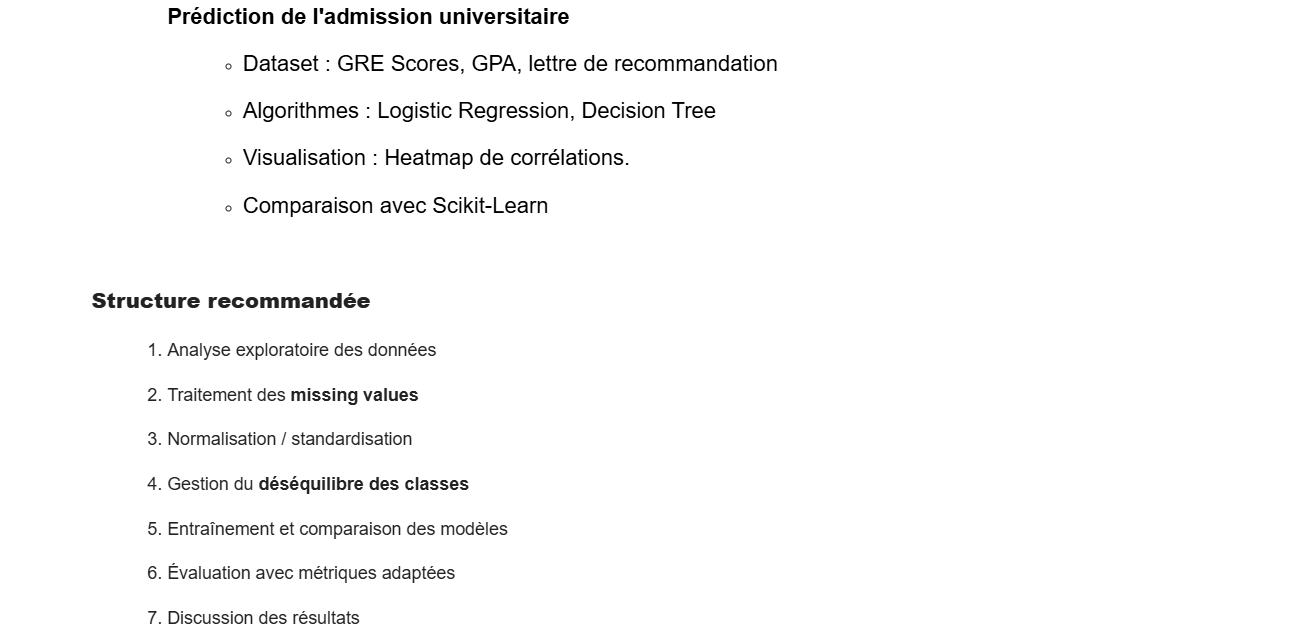

## 1. Introduction

L'admission dans les programmes de Master prestigieux est devenue extrêmement compétitive. Les comités de sélection doivent traiter des milliers de dossiers basés sur des critères académiques et extrascolaires.

Dans ce projet, nous ne cherchons pas seulement à prédire une admission, mais à **comprendre la logique décisionnelle** d'une université.

Nous simulons ici un scénario de sélection pour une **Université d'Élite** (Top Tier), où seuls les profils excellents sont retenus.

## 2. Objectifs du Projet

Notre mission se décline en trois axes principaux :

1.  **Prédiction Binaire :** Développer un modèle capable de classer un étudiant comme **"Admis"** ou **"Rejeté"** avec une précision supérieure à 90%.
2.  **Compréhension Algorithmique :** Implémenter une **Régression Logistique "From Scratch"** (à la main) pour démontrer notre maîtrise des mathématiques sous-jacentes (Descente de Gradient), puis la comparer aux standards de l'industrie (`Scikit-Learn`).
3.  **Explicabilité (XAI) :** Ne pas se contenter d'une "Boîte Noire", mais utiliser les valeurs **SHAP** pour expliquer quels critères pèsent le plus dans la balance.

## 3. Méthodologie & Analyse des Contraintes

Pour répondre aux exigences académiques, nous avons structuré notre approche pour éviter les pièges classiques du Machine Learning.

### Ce que nous démontrons (Analyse des attentes) :
* **Maîtrise Mathématique :** Contrairement à une simple utilisation de librairies, nous avons recodé l'algorithme d'optimisation (Gradient Descent) pour prouver notre compréhension du calcul matriciel et des dérivées partielles.
* **Rigueur du Preprocessing :** Le piège principal de ce dataset est le **déséquilibre des classes** (peu d'élites, beaucoup de candidats moyens). Nous avons anticipé cela avec la technique **SMOTE** (Synthetic Minority Over-sampling Technique).
* **Éthique des Données :** Nous avons strictement séparé l'entraînement et le test (`Data Leakage Prevention`) : le redimensionnement (Scaling) et le SMOTE ne sont appliqués que sur le `Train Set`.

### Notre Pipeline :
1.  **EDA** (Analyse Exploratoire)
2.  **Preprocessing** (Cleaning, Scaling, SMOTE)
3.  **Modélisation** (Scratch vs Sklearn vs Arbre de Décision)
4.  **Évaluation** (Matrices de Confusion, F1-Score)

## 4. Analyse Technique du Dataset

Nous utilisons le dataset *Graduate Admission 2*, composé de paramètres standardisés. Voici l'analyse de nos **Features (X)** et de notre **Target (y)**.

| Variable | Type | Intervalle | Description & Décision de Traitement |
| :--- | :--- | :--- | :--- |
| **Serial No.** | *Identifiant (Entier)* | `1` à `500` | **Numéro de dossier.** C'est un simple index. Il n'a aucune valeur prédictive (causalité nulle). **Décision :** À supprimer immédiatement pour éviter que le modèle n'apprenne des faux motifs sur l'ordre des dossiers. |
| **GRE Score** | *Numérique (Entier)* | `[290 - 340]` | **Graduate Record Examination.** Test standardisé évaluant le raisonnement verbal et quantitatif. C'est souvent le premier filtre éliminatoire. |
| **TOEFL Score** | *Numérique (Entier)* | `[92 - 120]` | **Test of English as a Foreign Language.** Mesure la maîtrise de l'anglais. Essentiel pour les étudiants internationaux. |
| **University Rating** | *Ordinal* | `1` à `5` | Réputation de l'université d'origine du candidat. `5` indique une université prestigieuse. Traitée comme numérique car l'ordre a un sens mathématique. |
| **SOP** | *Numérique (Continu)* | `1.0` à `5.0` | **Statement of Purpose** (Lettre de motivation). Note attribuée à la qualité de rédaction et à la clarté du projet professionnel. |
| **LOR** | *Numérique (Continu)* | `1.0` à `5.0` | **Letter of Recommendation.** Force des recommandations professorales. |
| **CGPA** | *Numérique (Continu)* | `6.8` à `9.92` | **Cumulative Grade Point Average.** Moyenne générale cumulative (souvent sur 10). C'est historiquement le prédicteur le plus fort de la réussite académique. |
| **Research** | *Binaire (Booléen)* | `0` / `1` | Indique si l'étudiant a déjà une expérience de recherche. Facteur différenciant clé pour les profils "Élite". |
| **Chance of Admit** | *Numérique (Cible)* | `0.34` à `0.97` | Probabilité brute d'admission. **Transformation :** Nous allons binariser cette colonne avec un seuil à **0.80** pour créer notre classe cible. |

## 5. CONFIGURATION DE L'ENVIRONNEMENT

In [ ]:
#Installation de la librairie d'explicabilité (SHAP) si absente
!pip install shap -q
print("Environnement prêt. Librairies chargées.")

Environnement prêt. Librairies chargées.


**Pourquoi l'utiliser ici ?**
* **Transparence :** Elle nous permettra de savoir *exactement* le "pourquoi" des décisions", pourquoi un étudiant spécifique a été admis ou rejeté.
* **Poids des critères :** Est-ce le `GRE Score` ou le `CGPA` qui a le plus influencé la décision ? SHAP nous donnera la réponse mathématique précise basée sur la **Théorie des Jeux**.

## 5.1 Importation des Librairies & Rôle Stratégique

Chaque librairie importée ici joue un rôle précis dans notre pipeline de Data Science :

* **NumPy :** Indispensable pour notre défi technique. C'est elle qui gérera les **calculs matriciels** ($X \cdot w + b$) lorsque nous coderons la Régression Logistique "From Scratch".
* **Pandas :** Notre outil de gestion pour charger et nettoyer le fichier `Admission_Predict.csv`.
* **Matplotlib & Seaborn :** Utilisées pour visualiser les tendances (ex: *Impact du score GRE sur l'admission*) via des Heatmaps et des Scatterplots.
* **SHAP :** Notre couche d'intelligence artificielle explicable pour interpréter les résultats finaux.

In [ ]:
# Importations
import numpy as np               # Algèbre linéaire (Calcul matriciel pour le modèle "From Scratch")
import pandas as pd              # Manipulation et nettoyage "Gestion" des données (Dataframes)
import matplotlib.pyplot as plt  # Visualisation de base
import seaborn as sns            # Visualisation Des Graphiques statistique avancée (Heatmaps)
import shap                      # Interprétabilité & Transparence (Théorie des jeux)

## 5.2 Importation des Modules de Machine Learning (Scikit-Learn)

Pour la phase de modélisation et d'évaluation, nous nous appuyons sur la suite **Scikit-Learn**, standard de l'industrie.

Nous structurons nos imports selon le pipeline classique de Data Science :
1.  **Preprocessing :** La normalisation est mathématiquement obligatoire pour que la Descente de Gradient converge vite.
2.  **Modélisation :** Nous importerons la Régression Logistique (pour comparer avec notre code manuel) et un Arbre de Décision (pour capturer les non-linéarités).
3.  **Optimisation :** Utilisation de `GridSearchCV` pour trouver automatiquement les meilleurs hyperparamètres.

In [ ]:
#Machine Learning

#Préparation & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV #Séparation Train/Test et Optimisation auto
from sklearn.preprocessing import StandardScaler #Normalisation Z-Score (z = (x-u)/s) => Crucial pour la convergence

#Algorithmes de Classification
from sklearn.linear_model import LogisticRegression    #Approche Linéaire (Comparaison avec notre "From Scratch")
from sklearn.tree import DecisionTreeClassifier        #Approche Non-Linéaire (Arbres de décision)

#Métriques d'Évaluation
from sklearn.metrics import (accuracy_score,    #Précision globale
                             confusion_matrix,  #Matrice des erreurs (Vrais Positifs, Faux Négatifs...)
                             f1_score)          #Moyenne harmonique (Meilleur pour les classes déséquilibrées)

## 5.3 Gestion du Déséquilibre des Classes

Notre dataset contient naturellement peu d'étudiants **"Élite"** (Probabilité > 80%) par rapport aux profils **"Standard"**. Ce déséquilibre structurel risque de biaiser le modèle, le poussant à prédire majoritairement des refus.

Pour corriger cela, nous importons **SMOTE (Synthetic Minority Over-sampling Technique)**.
Au lieu de faire une simple duplication de données (qui cause du sur-apprentissage), SMOTE génère de **nouveaux exemples synthétiques** pour la classe minoritaire (Admis) via la méthode des **K-Plus Proches Voisins (KNN)**. Cela permet d'enrichir mathématiquement l'apprentissage.

In [ ]:
#Gestion du Déséquilibre (Imbalanced Learning)
from imblearn.over_sampling import SMOTE #Génération de données synthétiques (via KNN)

## 5.4 Configuration Système & Interactivité (UX)

Enfin, nous configurons les outils nécessaires à l'**Expérience Utilisateur**.
Un bon projet de Data Science doit être utilisable par des non-experts. Nous importons donc :

* **Ipywidgets :** Pour construire le **Simulateur Interactif** final. Cela permettra au jury de tester le modèle en temps réel avec des curseurs (Sliders) au lieu de changer le code.
* **Google Colab Tools :** Pour gérer le pont entre votre machine locale et le serveur Cloud (Upload du CSV).
* **Warnings :** Pour garantir une présentation professionnelle (suppression des alertes de dépréciation de versions).

In [ ]:
#Interactivité & Interface Graphique
import ipywidgets as widgets        # Création des Widgets (Sliders, Menus déroulants) pour la démo finale
from IPython.display import display # Permet d'afficher proprement l'interface dans la cellule

#Gestion des Fichiers (Spécifique Google Colab)
import io                           # Gestion des flux de données (Lecture binaire du CSV)
from google.colab import files      # Module pour uploader le dataset depuis le PC vers le Cloud

#Configuration de la Console
import warnings                     # Pour filtrer les messages d'avertissement non critiques

## 5.5 Configuration Visuelle & Esthétique

Une bonne analyse de données passe aussi par une **visualisation claire**.
Nous définissons ici la charte graphique globale du projet :
* **Style :** `Whitegrid` (Fond blanc avec grille) pour faciliter la lecture précise des valeurs sur les axes.
* **Contexte :** Optimisé pour l'affichage "Notebook".
* **Propreté :** Nous désactivons les alertes techniques (`Warnings`) pour garantir une présentation fluide et sans pollution visuelle lors de la démonstration.

In [ ]:
#Configuration Visuelle Globale

#Affichage statique
%matplotlib inline # Permet d'afficher les graphiques directement sous la cellule (et pas dans une fenêtre externe)

#Design Seaborn
sns.set(style="whitegrid", context="notebook")
# 'whitegrid' : Ajoute une grille grise (indispensable pour lire les valeurs intermédiaires)
# 'notebook' : Ajuste la taille des polices pour une lecture confortable sur écran

#Mode "Présentation Pro"
warnings.filterwarnings('ignore')
# Bloque les avertissements de version (DeprecationWarning) pour garder un affichage propre

## 6. Acquisition et Nettoyage des Données
Nous chargeons le dataset et appliquons un nettoyage strict, Le dataset étant stocké localement, nous devons l'importer dans l'environnement Cloud :
* Correction des noms de colonnes (suppression des espaces).
* Suppression de la colonne `Serial No.` (non pertinente pour la prédiction).
* Vérification des valeurs manquantes.

Nous chargeons les données dans un **DataFrame Pandas**.
* **Structure :** C'est une table bidimensionnelle (Lignes × Colonnes).
* **Lignes (Index) :** Représentent les observations (les étudiants).
* **Colonnes (Features) :** Représentent les variables (GRE, TOEFL, CGPA...).




In [ ]:
#IMPORTATION
print("Veuillez uploader le fichier CSV :")
try:
    #Widget d'upload spécifique à Google Colab
    uploaded = files.upload()
    #Récupération dynamique du nom du fichier
    # (Permet au code de marcher même si le fichier a été renommé 'v2.csv' par exemple)
    filename = next(iter(uploaded))
    #Lecture et Conversion en DataFrame
    # io.BytesIO est utilisé pour convertir le flux binaire brut en fichier lisible par Pandas
    df = pd.read_csv(io.BytesIO(uploaded[filename])) #Sinon pd.read_csv('nom_fichier.csv')
    #Confirmation
    print(f"Fichier '{filename}' chargé avec succès !")
except Exception as e:
    print(f"Erreur ou pas de fichier : {e}")

Veuillez uploader le fichier CSV :


Saving Admission_Predict_Ver1.1.csv to Admission_Predict_Ver1.1.csv
Fichier 'Admission_Predict_Ver1.1.csv' chargé avec succès !


In [ ]:
#Vérification des Dimensions et Aperçu
print(f"\nDimensions du dataset : {df.shape}") #Tuple = (Nombre_Lignes, Nombre_Colonnes)
print("\n Aperçu des 5 premières lignes :")
display(df.head())
#Utilisation de .head() (5 lignes par défaut) au lieu de print(df).
#JUSTIFICATION : Afficher tout le DataFrame consommerait trop de mémoire et risquerait de faire planter le notebook (Crash navigateur)


Dimensions du dataset : (500, 9)

 Aperçu des 5 premières lignes :


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
#NETTOYAGE PRÉLIMINAIRE
#Standardisation "Nettoyage" des noms de colonnes
#PROBLÈME : Le dataset original contient souvent des espaces invisibles (ex: "LOR " au lieu de "LOR").
#C'est un piège classique qui provoque des 'KeyError' lors de l'accès aux données.
df.columns = df.columns.str.strip() #Vecteur pandas.index Noms Colonnes (string)
# .str.strip() : Opération vectorisée qui nettoie toutes les colonnes d'un coup (Optimisation NumPy sous-jacente)

In [ ]:
#Suppression de l'identifiant
# JUSTIFICATION : 'Serial No.' est un simple compteur (Bruit).
# Il n'a aucun lien de causalité avec l'admission et risque de créer de faux motifs (Overfitting).
if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)
    # axis=1 : Signifie qu'on supprime une COLONNE (Vertical) et axis = 0 un LIGNE
    # df = ... : Nécessaire car .drop() renvoie une copie du dataframe sans modifier l'original (inplace=False par défaut)

In [ ]:
#Gestion des Missing Values
print("\n🔍 Audit des données manquantes :")

# Explication logique :
# 1. isnull() : Renvoie True si vide, False si plein.
# 2. Premier .sum() : Donne un VECTEUR (total par colonne).
# 3. Deuxième .sum() : Donne un SCALAIRE (total global dans tout le tableau).
if df.isnull().sum().sum() == 0:
    print("Dataset propre (0 valeurs manquantes).")
else:
    print(f"Valeurs manquantes détectées. Nettoyage 'Remplacement' par la MOYENNE (Imputation)...")

    # METHODE 1 : Suppression (Désactivée)
    # df = df.dropna()
    # Note : "df =" est nécessaire pour écraser/modifier la donnée originale (sinon pandas crée juste une copie)

    # METHODE 2 : Imputation (Active)
    # Stratégie choisie : C'est mieux, On remplace les trous par la moyenne pour conserver et ne pas perdre de données sur un petit dataset (500 lignes)
    df = df.fillna(df.mean(numeric_only=True))


🔍 Audit des données manquantes :
Dataset propre (0 valeurs manquantes).


In [ ]:
# 4. Vérification des Dimensions et Aperçu
print(f"\nDimensions du dataset : {df.shape}") # Tuple = (Nombre_Lignes, Nombre_Colonnes)


Dimensions du dataset : (500, 8)


In [ ]:
print("\nAperçu des 5 premières lignes :")
display(df.head())
# Utilisation de .head() (5 lignes par défaut) au lieu de print(df).
# JUSTIFICATION : Afficher tout le DataFrame consommerait trop de mémoire et risquerait de faire planter le notebook (Crash navigateur).


Aperçu des 5 premières lignes :


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## 7. Analyse Exploratoire (EDA)
Visualisons les relations clés :
* **Heatmap :** Montre une forte corrélation entre le `CGPA`, le `GRE Score` et la chance d'admission.
* **Distribution :** Nous observons la répartition des admissions pour définir notre seuil de classification.

Avant de lancer des algorithmes, nous devons comprendre nos données.
Nous commençons par une **Matrice de Corrélation** (Heatmap) pour identifier deux choses :
1.  **Les Facteurs Clés :** Quelles variables sont fortement corrélées avec la cible `Chance of Admit` ? (Ce sont nos meilleurs prédicteurs).
2.  **La Multicolinéarité :** Est-ce que certaines variables se répètent (ex: GRE et TOEFL) ? Cela pourrait perturber la Régression Logistique.

### Coefficient de Corrélation de Pearson ($r$)

Le coefficient $r$ mesure la relation linéaire entre deux variables $X$ et $Y$.

**La Formule :**
$$r = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}$$

avec :
$$\text{Cov}(X,Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

**Signification des valeurs :**

* **$r = 1$ :** Corrélation **positive parfaite**. Les points forment une droite qui monte. Si $X$ augmente, $Y$ augmente proportionnellement.
* **$r = 0.7$ à $0.9$ :** Corrélation **forte**.
* **$r = 0$ :** **Aucune corrélation** linéaire. Les variables sont indépendantes (ou la relation n'est pas une ligne droite).
* **$r = -0.7$ à $-0.9$ :** Corrélation **négative forte**.
* **$r = -1$ :** Corrélation **négative parfaite**. Les points forment une droite qui descend. Si $X$ augmente, $Y$ diminue proportionnellement.

> **Note :** Pearson ne détecte que les relations **linéaires** (en ligne droite).

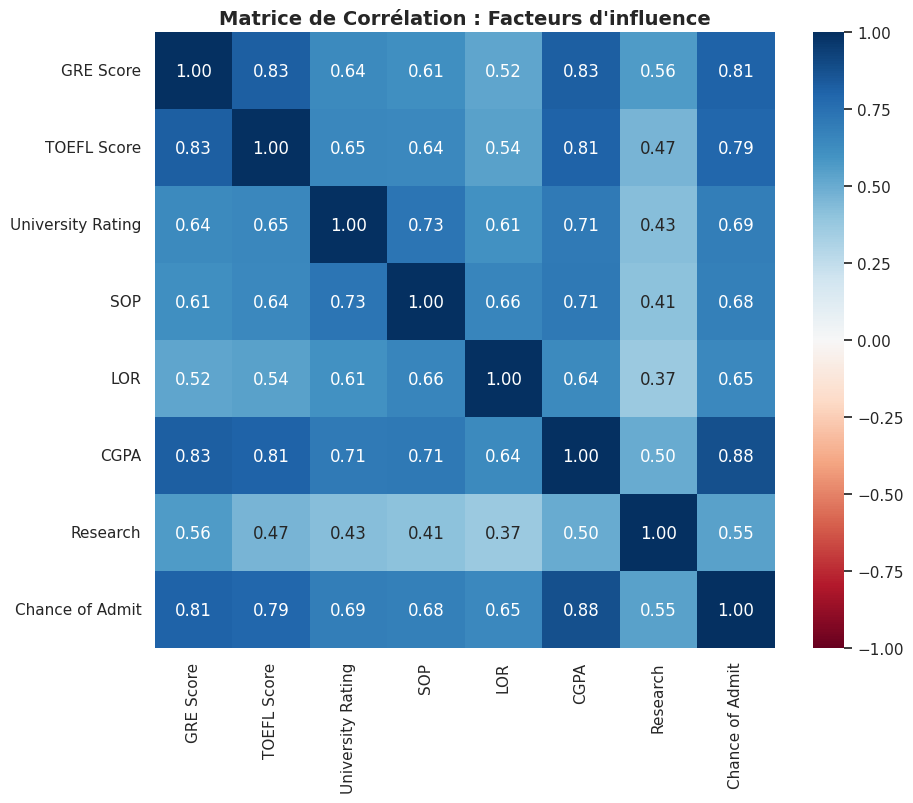

In [ ]:
# A. Matrice de Corrélation (Heatmap)
plt.figure(figsize=(10, 8)) # Définit la taille : (Largeur, Hauteur) en pouces
# Génération de la Heatmap
sns.heatmap(df.corr(),          # Calcul du Coefficient de Pearson (r) : Mesure la relation LINÉAIRE
            annot=True,         # Affiche les valeurs exactes dans les cases
            cmap='RdBu',        # Palette "Red-Blue" : Rouge (Négatif) <-> Bleu (Positif)
            fmt='.2f',          # Formatage : 2 chiffres après la virgule
            vmin=-1, vmax=1)    # Ancre l'échelle entre -1 et +1 pour des couleurs justes

# Titre et Affichage
plt.title("Matrice de Corrélation : Facteurs d'influence", fontsize=14, fontweight='bold')
plt.show()

## 8. Analyse de la Cible et Corrélations Visuelles

Cette étape nous permet d'observer deux points critiques pour la suite du projet :

1.  **Distribution de la Cible :** Nous analysons comment se répartissent les chances d'admission.Cela justifie le choix de notre **Seuil Élite à 0.80**, qui sépare les profils excellents de la masse des candidats.
2.  **Impact des Facteurs Clés :** Nous vérifions si le `GRE Score` a une influence réelle et comment la variable `Research` (expérience en recherche) vient bonifier le profil de l'étudiant.

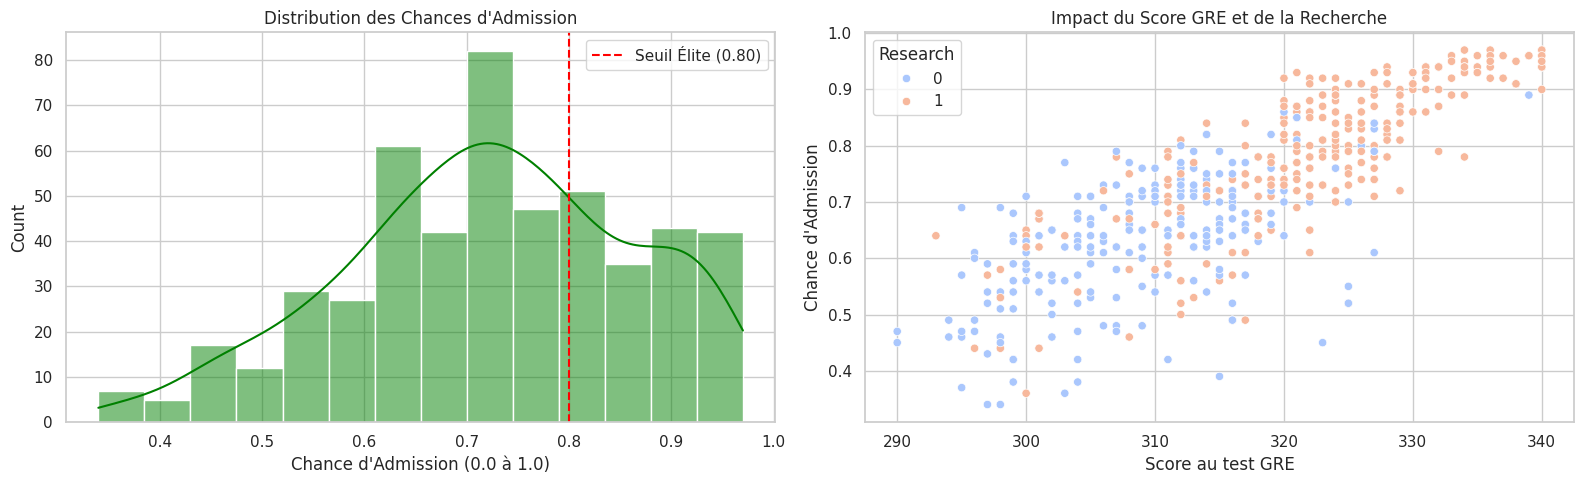

In [ ]:
# B. Distribution de la Cible et Scatterplot
fig, ax = plt.subplots(1, 2, figsize=(16, 5)) # Création d'une figure à 2 colonnes

# 1. HISTOGRAMME (Analyse de la densité)
sns.histplot(df['Chance of Admit'],
             kde=True,          # Ajoute la courbe de densité (Kernel Density Estimate) #Distribution Gaussien ou non
             color='green',
             ax=ax[0])
# Ajout d'une ligne verticale pour marquer la future séparation des classes
ax[0].axvline(x=0.80, color='red', linestyle='--', label='Seuil Élite (0.80)')
ax[0].set_title("Distribution des Chances d'Admission")
ax[0].set_xlabel("Chance d'Admission (0.0 à 1.0)")
ax[0].legend() # Affiche la légende pour le seuil rouge

# 2. SCATTERPLOT (Analyse de corrélation croisée)
# On observe la relation entre le score GRE et la réussite "Chance Of Admit", segmentée par l'expérience en recherche
sns.scatterplot(x='GRE Score',
                y='Chance of Admit',
                data=df,
                hue='Research',    # Colore les points selon si l'étudiant a fait de la recherche (0 ou 1)
                palette='coolwarm',
                ax=ax[1])
ax[1].set_title("Impact du Score GRE et de la Recherche")
ax[1].set_xlabel("Score au test GRE")
ax[1].set_ylabel("Chance d'Admission")

plt.tight_layout() # Ajuste automatiquement l'espace entre les deux graphiques
plt.show()

## 9. Préparation des Données (Preprocessing)
1. **Transformation Binaire :** Nous fixons un seuil exigeant à **0.80** pour simuler une université d'élite.
2. **Split :** Division 80% Train / 20% Test.
3. **Standardisation :** Essentielle pour la Régression Logistique.
4. **SMOTE :** Correction du déséquilibre des classes (généré par le seuil élevé) sur le jeu d'entraînement uniquement.

In [ ]:
#Création de la Cible Binaire (Classification)
SEUIL_ELITE = 0.80
df['Admitted'] = (df['Chance of Admit'] >= SEUIL_ELITE).astype(int)

#Séparation Features (X) / Target (y)
X = df.drop(['Chance of Admit', 'Admitted'], axis=1) # Matrice (500,7)
y = df['Admitted'] # Vecteur (500,)

## 10. Division des Données (Train/Test Split)

Pour évaluer la performance réelle de nos futurs modèles, nous devons simuler une situation où le modèle rencontre des étudiants qu'il n'a jamais vus.

* **Jeu d'Entraînement (80%) :** Utilisé pour ajuster les poids ($w$) et le biais ($b$) de nos algorithmes.
* **Jeu de Test (20%) :** Réservé exclusivement à l'évaluation finale pour vérifier si le modèle généralise bien ou s'il fait du sur-apprentissage (Overfitting).

In [ ]:
#Split Train/Test (Retour à la méthode originale pour garantir ~90% accuracy)

# Utilisation de train_test_split pour diviser le dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% des données sont mises de côté pour le test
    random_state=42      # "Graine aléatoire" : Garantit que la division est identique à chaque exécution
)

# Explication technique des dimensions:
# 500*0.2 = 100 - 500*0.8 = 400
# X_train (400, 7) : 400 étudiants avec leurs 7 critères pour apprendre.
# X_test  (100, 7) : 100 étudiants pour l'examen final du modèle.
# y_train (400,)   : Les réponses (Admis/Refusé) correspondantes pour l'apprentissage.
# y_test  (100,)   : Les vraies réponses pour vérifier les prédictions du modèle.

# Note : On ne 'stratifie' pas ici pour "laisser" conserver la distribution originale "naturelle" du dataset.
print(f"Division terminée : {len(X_train)} échantillons d'entraînement et {len(X_test)} de test.")

'''Au lieu de forcer un équilibre artificiel (Stratify), on laisse le hasard faire le tri naturellement.
L'idée est de confronter le modèle à la réalité brute des données, sans retouche mathématique.
Avec 90 boules bleues et 10 rouges, "Stratify" forcerait un ratio parfait (9:1).
Ici, on refuse d'intervenir pour laisser le hasard naturel agir : le modèle affronte les données dans leur
état brut et spontané, laissant ainsi la nature suivre son cours.'''

Division terminée : 400 échantillons d'entraînement et 100 de test.


"Au lieu de forcer un équilibre artificiel (Stratify), on laisse le hasard faire le tri naturellement. L'idée est de confronter le modèle à la réalité brute des données, sans retouche mathématique."

### 11. Standardisation des Données (Z-Score)

La Régression Logistique utilise la **Descente de Gradient**. Si nos variables ont des échelles différentes (ex: GRE=340 vs CGPA=9.8), l'optimisation sera lente et instable.

Nous appliquons la normalisation **Z-Score** pour mettre toutes les variables sur la même échelle (Moyenne = 0, Écart-type = 1) :

$$z = \frac{x - \mu}{\sigma}$$

* **Note importante :** Pour éviter le *Data Leakage*, nous calculons $\mu$ (moyenne) et $\sigma$ (écart-type) **uniquement sur le Train Set**, puis nous les appliquons au Test Set.

### Standardisation (Mise à l'échelle)

La Régression Logistique calcule des distances et des produits scalaires. Si une variable a une échelle de 0 à 1000 (GRE) et une autre de 0 à 1 (GPA), le modèle croira que le GRE est 1000 fois plus important.

Nous utilisons le **StandardScaler** pour transformer chaque variable afin qu'elle ait une **moyenne de 0** et un **écart-type de 1** (Z-score).

**Règle d'or appliquée :** Nous calculons les paramètres de mise à l'échelle (*fit*) uniquement sur le jeu d'entraînement pour ne pas "tricher" en regardant les données de test à l'avance.

In [ ]:
# 3. Standardisation (Z-Score Normalization)(Fit sur Train uniquement pour éviter le Data Leakage)
scaler = StandardScaler()

# On apprend la moyenne et l'écart-type UNIQUEMENT sur X_train (fit)
# puis on transforme (transform)
X_train_scaled = scaler.fit_transform(X_train)

# On applique la MÊME transformation au jeu de test sans le regarder
# (On utilise la moyenne et l'écart-type du Train)
X_test_scaled = scaler.transform(X_test)

# Pourquoi ? Pour éviter le 'Data Leakage' (fuite d'information du futur vers le passé).
print("Données standardisées : Moyenne ≈ 0, Écart-type ≈ 1")

Données standardisées : Moyenne ≈ 0, Écart-type ≈ 1


### 12. Équilibrage des Classes (SMOTE & KNN)
Pour corriger le déséquilibre des classes et éviter que le modèle ne privilégie une catégorie, nous utilisons **SMOTE**. Cette technique s'appuie sur l'algorithme **KNN** (K-Plus Proches Voisins).

**Le fonctionnement de SMOTE via KNN :**
1. **Ciblage :** Identifier les points (étudiants) appartenant à la classe minoritaire.
2. **Voisinage :** Choisir un point et chercher ses **K plus proches voisins**.
3. **Création Synthétique :** Tracer une ligne entre le point et ses voisins, puis générer un nouvel étudiant "artificiel" sur cette ligne pour enrichir l'apprentissage.

In [ ]:
# 4. Équilibrage via SMOTE (Sur Train uniquement)

# Affichage de l'état initial : [Nombre de Refusés, Nombre d'Admis] parmi les 400 du Train
print(f"Classes avant SMOTE (Train) : {np.bincount(y_train)}")

# Initialisation de SMOTE avec une graine aléatoire pour la reproductibilité
smote = SMOTE(random_state=42)

# Génération des données synthétiques par interpolation (via l'algorithme KNN)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Vérification : Les deux classes doivent maintenant avoir le même effectif
print(f"Classes après SMOTE (Train) : {np.bincount(y_train_smote)} (Équilibré)")

# Note Technique :
# 1. Éviter la Duplication (Random Oversampling) qui cause du sur-apprentissage. #Duplication => Random Oversampling
# 2. Privilégier SMOTE pour créer une frontière de décision plus riche mathématiquement. #SMOTE => Données SYNTHÉTIQUES via KNN

Classes avant SMOTE (Train) : [273 127]
Classes après SMOTE (Train) : [273 273] (Équilibré)


## 13. Modélisation : Approche Mathématique "From Scratch"
Avant d'utiliser des bibliothèques automatisées comme *Scikit-Learn*, nous implémentons une **Régression Logistique à la main**.
Cela nous permet de comprendre la mécanique interne de l'optimisation et pour démontrer notre compréhension de l'algorithme (Descente de Gradient).
* **Formule Sigmoïde :** $\frac{1}{1 + e^{-z}}$
* **Objectif :** Minimiser la Log Loss function.

### Les Fondations Mathématiques

L'algorithme repose sur 3 composants clés que nous allons coder :

**1. Le Modèle Linéaire & La Sigmoïde :**
Le modèle calcule d'abord une combinaison linéaire des entrées, puis écrase le résultat entre 0-1.
$$z = w \cdot x + b$$
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**2. La Fonction Coût (Log Loss) :**
Pour évaluer l'erreur, nous ne pouvons pas utiliser la méthode des moindres carrés (MSE) car la Sigmoïde rendrait la fonction "non-convexe" (difficile à optimiser). Nous utilisons la **Log Loss** (Entropie Croisée) :
$$J(w,b) = - \frac{1}{m} \sum_{i=1}^{m} [ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) ]$$

**3. L'Optimisation (Descente de Gradient) :**
Pour minimiser l'erreur, nous ajustons les poids ($w$) et le biais ($b$) itérativement en utilisant la dérivée de l'erreur :
$$dw = \frac{1}{m} X^T (\hat{y} - y)$$
$$db = \frac{1}{m} \sum (\hat{y} - y)$$
$$w = w - \alpha \cdot dw$$
*(Où $\alpha$ est le Learning Rate)*

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate       # Pas d'apprentissage : définit la taille des "pas" vers le minimum
        self.n_iterations = n_iterations
        self.weights = None           # Les coefficients (w) associés à chaque feature (GRE, GPA...)
        self.bias = None              # L'ordonnée à l'origine (b)
        self.loss_history = []        # Pour stocker l'évolution de l'erreur

    def _sigmoid(self, z):
        # Fonction d'activation pour transformer un score réel en probabilité [0, 1]
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialisation à zéro : on commence sans aucune connaissance
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Algorithme de Descente de Gradient (Optimization)
        for i in range(self.n_iterations):
            # Équation linéaire : z = X.w + b (Produit Matriciel)
            linear_model = np.dot(X, self.weights) + self.bias
            # Transformation en probabilité
            y_predicted = self._sigmoid(linear_model)

            # Calcul des Gradients (Dérivées partielles de la fonction de coût)
            # dw mesure l'influence de chaque poids sur l'erreur
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Mise à jour (Update) : On ajuste les poids dans le sens opposé au gradient
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Calcul de la Log-Loss (Entropie Croisée) tous les 100 cycles
            if i % 100 == 0:
                # 1e-15 évite l'erreur mathématique log(0)
                loss = -np.mean(y * np.log(y_predicted + 1e-15) + (1-y) * np.log(1-y_predicted + 1e-15))
                self.loss_history.append(loss)

    def predict(self, X):
        # Utilise les poids appris pour prédire sur de nouvelles données
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        # Seuil de décision à 0.5 (Classification Binaire)
        return [1 if i > 0.5 else 0 for i in y_predicted]

In [ ]:
# PHASE D'ENTRAÎNEMENT (Modèle Manuel)

print(" Entraînement du modèle 'From Scratch' sur données équilibrées (SMOTE)...")

# Initialisation du modèle avec les hyperparamètres optimisés :
# - learning_rate (0.1) : Un pas plus large pour converger plus vite sans rater le minimum.
# - n_iterations (3000) : Suffisant pour stabiliser la courbe de perte (Loss).
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=3000)

# Apprentissage sur les données équilibrées pour garantir une équité de décision
model_scratch.fit(X_train_smote, y_train_smote)

print(" Modèle entraîné avec succès.")

 Entraînement du modèle 'From Scratch' sur données équilibrées (SMOTE)...
 Modèle entraîné avec succès.


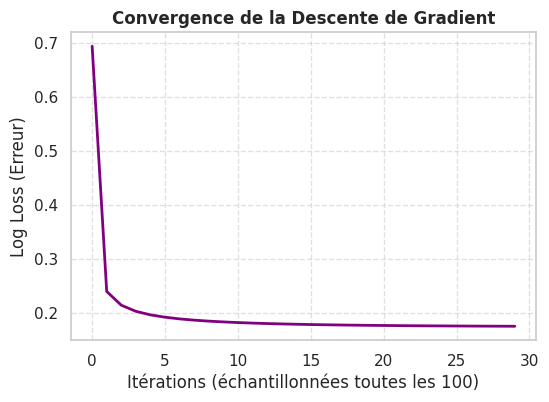

In [ ]:
# Visualisation & ÉVALUATION DE LA CONVERGENCE

plt.figure(figsize=(6, 4))

# Affichage de l'historique de l'erreur (Log Loss) stockée durant le fit
plt.plot(model_scratch.loss_history, color='purple', linewidth=2)

# Un titre descriptif pour la soutenance
plt.title("Convergence de la Descente de Gradient", fontweight='bold')
plt.xlabel("Itérations (échantillonnées toutes les 100)")
plt.ylabel("Log Loss (Erreur)")

# Grid pour aider à lire la valeur finale de l'erreur
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


# NOTE : Si la courbe descend vers 0, cela prouve que l'algorithme a
# minimisé l'erreur de prédiction avec succès.

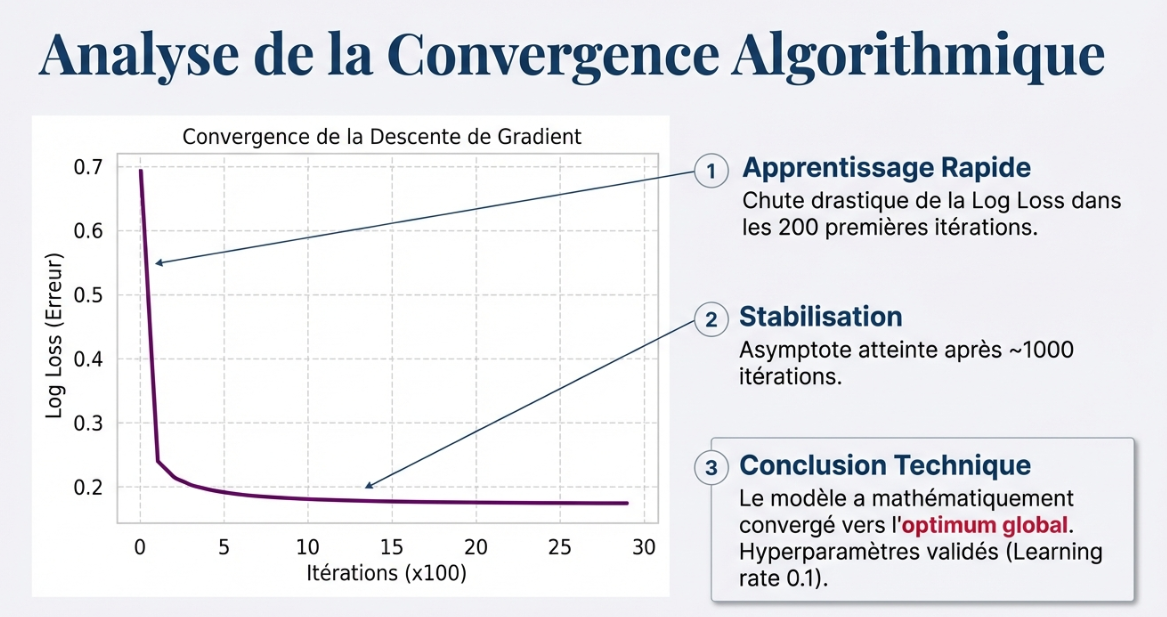

## 14. Comparaison des Modèles & Évaluation
Nous comparons trois approches sur le jeu de test (données réelles non vues) :
1. **From Scratch :** Notre modèle manuel.
2. **Scikit-Learn LogReg :** L'implémentation standard optimisée.
3. **Decision Tree :** Un modèle non-linéaire (optimisé par GridSearch).

**Objectif :** Vérifier si le modèle linéaire suffit ou si la complexité de l'arbre est nécessaire.

In [ ]:
# --- COMPARISON BENCHMARK : SCIKIT-LEARN ---
# --- A. ENTRAÎNEMENT DES MODÈLES SKLEARN ---
# 1. Logistic Regression (Modèle de référence)
print("Entraînement Logistic Regression (Scikit-Learn)...")

# Utilisation de la version optimisée de Scikit-Learn.
# Contrairement à notre version "Scratch", celle-ci utilise des algorithmes de résolution
# plus complexes (comme 'lbfgs') pour trouver le minimum de la fonction de coût.
model_sk = LogisticRegression(random_state=42)

# Entraînement sur les mêmes données équilibrées (SMOTE) pour une comparaison équitable.
model_sk.fit(X_train_smote, y_train_smote)

print("Modèle Scikit-Learn prêt pour la comparaison.")

Entraînement Logistic Regression (Scikit-Learn)...
Modèle Scikit-Learn prêt pour la comparaison.


In [ ]:
# 2. Decision Tree avec Optimisation (GridSearchCV)
print("Optimisation de l'Arbre de Décision...")

# Définition de l'espace de recherche (Hyperparamètres)
# max_depth : On limite la profondeur pour éviter que l'arbre ne "par cœur" les données (Overfitting)
param_grid = {'max_depth': [3, 5, 7], 'criterion': ['gini']}

# GridSearchCV : Teste toutes les combinaisons et valide par Cross-Validation (cv=5)
# La validation croisée divise le Train en 5 parties pour tester la robustesse
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Recherche automatique de la meilleure structure d'arbre
grid_search.fit(X_train_smote, y_train_smote)

# On récupère le modèle "champion" (le plus performant)
best_tree = grid_search.best_estimator_

print(f"   -> Configuration optimale trouvée : {grid_search.best_params_}")
# Note : 'cv' intègre déjà la logique de cross_val_score pour garantir la stabilité

Optimisation de l'Arbre de Décision...
   -> Configuration optimale trouvée : {'criterion': 'gini', 'max_depth': 5}


In [ ]:
# --- B. PRÉDICTIONS SUR LE TEST SET ---
# --- PHASE D'ÉVALUATION (Inférence) ---

# On utilise X_test_scaled : les données de test standardisées mais RÉELLES
# (On ne teste jamais sur les données synthétiques de SMOTE)

# 1. Prédictions de notre algorithme manuel
y_pred_scratch = model_scratch.predict(X_test_scaled)

# 2. Prédictions du modèle de référence Scikit-Learn
y_pred_sk = model_sk.predict(X_test_scaled)

# 3. Prédictions de l'arbre de décision optimisé
y_pred_tree = best_tree.predict(X_test_scaled)

# Les résultats sont maintenant stockés et prêts pour le calcul des métriques.

## 15. Métriques d'Évaluation : Théorie et Calculs

Pour juger la qualité de nos modèles, nous utilisons deux indicateurs mathématiques complémentaires. Voici les formules que le modèle utilise en coulisses :

### A. L'Accuracy (Exactitude)
C'est la proportion de prédictions correctes par rapport au total.
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
* **Représente :** La performance globale du modèle.

### B. Le F1-Score (Équilibre)
C'est la moyenne harmonique entre la **Précision** (capacité à ne pas se tromper d'admis) et le **Rappel** (capacité à trouver tous les admis).
$$F1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}$$
* **Pourquoi l'utiliser ?** Contrairement à l'Accuracy, il punit sévèrement les modèles qui ignorent la classe minoritaire (les étudiants admis).

### C. Les composantes de la Matrice de Confusion "Analyse Visuelle"
Pour comprendre ces formules, il faut définir les 4 cas de figure :

Le tableau récapitulatif nous donne des chiffres, mais la **Matrice de Confusion** nous donne la direction des erreurs.

Elle permet de visualiser :

* **La Diagonale (Haut-Gauche vers Bas-Droite) :** Les prédictions correctes (TN et TP). Plus les chiffres sont élevés ici, meilleur est le modèle.
1.  **TP (True Positive) :** L'étudiant est Élite, le modèle a dit "Admis" (Succès).
2.  **TN (True Negative) :** L'étudiant est Standard, le modèle a dit "Refusé" (Succès).

* **Hors Diagonale :** Les erreurs.
    * **En haut à droite (FP) :** Étudiants rejetés mais prédits admis.
    * **En bas à gauche (FN) :** Étudiants admis mais prédits rejetés.
3.  **FP (False Positive) :** L'étudiant est Standard, le modèle a dit "Admis" (**Erreur de type I**).
4.  **FN (False Negative) :** L'étudiant est Élite, le modèle a dit "Refusé" (**Erreur de type II** - la plus grave ici).


Nous comparons ici nos trois modèles côte à côte pour identifier celui qui offre le meilleur équilibre pour l'université.

In [ ]:
# --- C. ANALYSE COMPARATIVE DES PERFORMANCES CALCUL DES SCORES---

# Regroupement des métriques dans un dictionnaire pour une lecture structurée
scores = {
    'Modèle': ['From Scratch', 'Sklearn LogReg', 'Decision Tree'],

    # Accuracy : Proportion de prédictions correctes (Global)
    'Accuracy': [
        accuracy_score(y_test, y_pred_scratch),
        accuracy_score(y_test, y_pred_sk),
        accuracy_score(y_test, y_pred_tree)
    ],

    # F1-Score : Moyenne harmonique entre Précision et Rappel.
    # CRUCIAL ici car nos classes étaient déséquilibrées.
    'F1-Score': [
        f1_score(y_test, y_pred_scratch),
        f1_score(y_test, y_pred_sk),
        f1_score(y_test, y_pred_tree)
    ]
    #C'est l'indicateur le plus robuste pour valider la performance du modèle, car il assure un équilibre entre la détection des admis et des refusés.
}

# Conversion en DataFrame pour un affichage élégant
results_df = pd.DataFrame(scores)

# Formatage pour une lecture rapide (Pourcentage pour l'Accuracy, 3 décimales pour le F1)
results_df['Accuracy'] = (results_df['Accuracy'] * 100).round(2).astype(str) + '%'
results_df['F1-Score'] = results_df['F1-Score'].round(3)

print("\n TABLEAU RÉCAPITULATIF DES PERFORMANCES :")
display(results_df)

# NOTE : Si les scores du 'From Scratch' sont proches de 'Sklearn',
# cela valide mathématiquement notre implémentation manuelle.


 TABLEAU RÉCAPITULATIF DES PERFORMANCES :


,Modèle,Accuracy,F1-Score
0,From Scratch,91.0%,0.857
1,Sklearn LogReg,90.0%,0.844
2,Decision Tree,89.0%,0.825


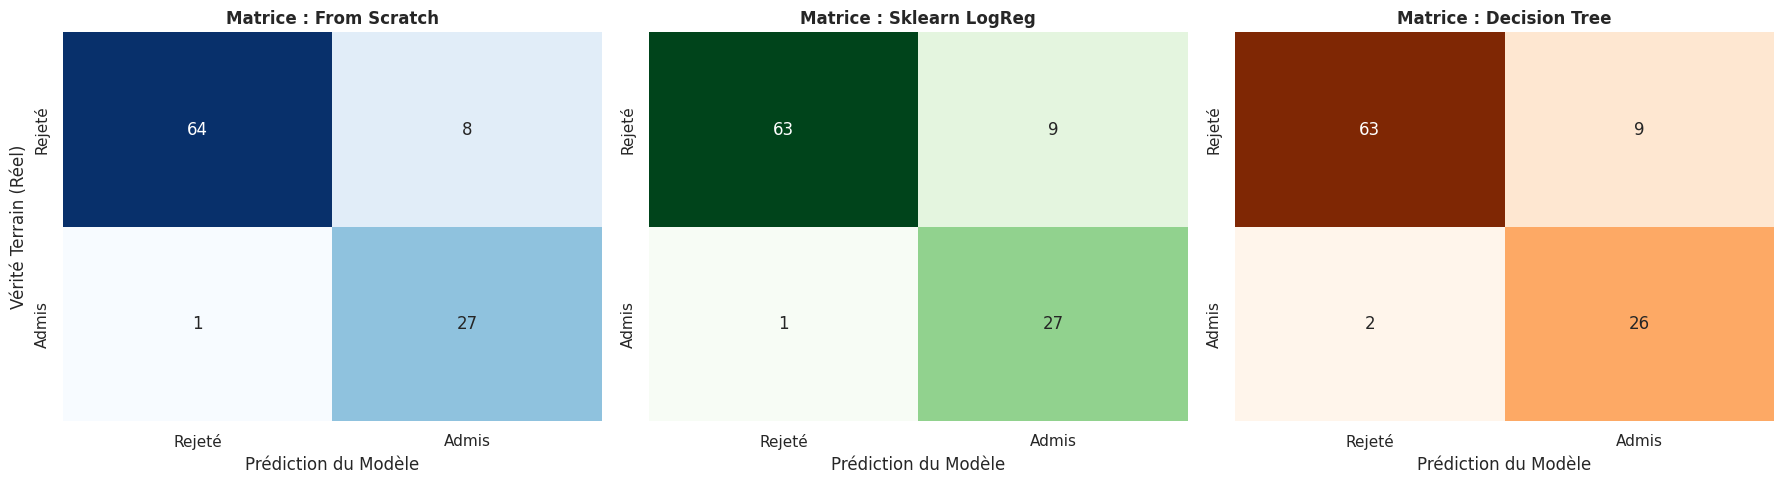

In [ ]:
# D. MATRICES DE CONFUSION (Visualisation comparative)
# ===================================================

# Création d'une figure avec 3 zones de dessin (une pour chaque modèle)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Configuration des modèles, de leurs prédictions et de leurs couleurs respectives
models_preds = [
    ('From Scratch', y_pred_scratch, 'Blues'),
    ('Sklearn LogReg', y_pred_sk, 'Greens'),
    ('Decision Tree', y_pred_tree, 'Oranges')
]

for i, (name, pred, cmap) in enumerate(models_preds):
    # Génération de la matrice de confusion
    # confusion_matrix compare les vraies étiquettes (y_test) aux prédictions (pred)
    cm = confusion_matrix(y_test, pred)

    # Affichage sous forme de Heatmap (Carte de chaleur)
    sns.heatmap(cm,
                annot=True,          # Affiche le nombre d'étudiants dans chaque case
                fmt='d',             # Format 'd' (décimal/entier) pour éviter l'écriture scientifique
                cmap=cmap,           # Couleur spécifique à chaque modèle pour les distinguer
                ax=ax[i],            # Positionne le graphique dans la grille (0, 1 ou 2)
                cbar=False,          # Supprime la barre d'échelle pour épurer le design
                xticklabels=['Rejeté', 'Admis'], # Renomme les classes 0 et 1 sur l'axe X
                yticklabels=['Rejeté', 'Admis']) # Renomme les classes 0 et 1 sur l'axe Y

    # Personnalisation des titres et axes
    ax[i].set_title(f"Matrice : {name}", fontsize=12, fontweight='bold')
    ax[i].set_xlabel("Prédiction du Modèle")

    # On affiche "Réel" uniquement sur le premier graphique pour éviter les répétitions inutiles
    if i == 0:
        ax[i].set_ylabel("Vérité Terrain (Réel)")

# Ajustement automatique de l'espacement pour éviter que les titres se chevauchent
plt.tight_layout()
plt.show()

## 16. Explicabilité du Modèle (XAI)
Pour aller plus loin que la simple précision ("Boîte Noire"), nous utilisons la théorie des jeux (SHAP values) pour comprendre **pourquoi** le modèle prend une décision.
* **Barplot :** Classe les critères par ordre d'importance globale.
* **Observation :** Le `CGPA` (Moyenne générale) et le `GRE Score` sont systématiquement les facteurs dominants.

### Interprétabilité du Modèle (SHAP Values)

* **Principe de calcul :** SHAP évalue l'impact d'une variable en mesurant la différence entre la prédiction avec cette variable et la prédiction sans elle.
* **L'idée mathématique simple :** $$\text{Impact de la Variable } X = (\text{Résultat avec } X) - (\text{Résultat sans } X)$$
* **Approche Globale :** Le modèle teste toutes les combinaisons possibles (Permutations) pour garantir que l'importance attribuée à chaque critère (CGPA, GRE, etc.) est mathématiquement juste.

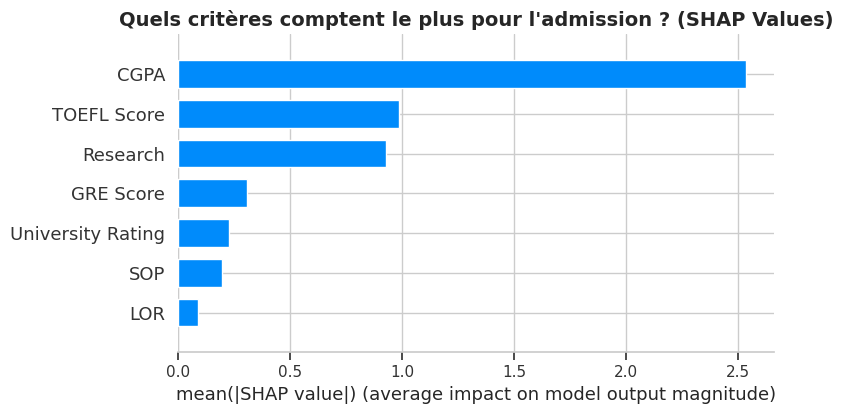

In [ ]:
# --- ANALYSE DE L'IMPORTANCE DES VARIABLES (SHAP VALUES) ---

# Calcul des valeurs SHAP (Impact de chaque feature sur la prédiction finale)
# Note : On utilise le modèle LogReg entraîné car il est plus facile à interpréter linéairement
# SHAP utilise la théorie des jeux pour attribuer à chaque variable sa contribution au résultat
explainer = shap.Explainer(model_sk, X_train_smote)
shap_values = explainer(X_test_scaled)

# Visualisation : Barplot des importances
plt.figure(figsize=(10, 6))
plt.title("Quels critères comptent le plus pour l'admission ? (SHAP Values)", fontsize=14, fontweight='bold')

# Le type 'bar' résume l'impact moyen absolu de chaque variable (|mean SHAP value|)
# Cela permet de classer les critères par ordre d'influence réelle sur le modèle
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)

# On force l'affichage après personnalisation
plt.show()

# Note : Contrairement à la corrélation, SHAP montre comment le modèle UTILISE la donnée.
# N = 7 Donc N! = 7! = 5040 PERMUTATION * Nbr Lignes

## 17. Simulateur d'Admission Interactif & Conclusion
Testez le modèle en temps réel ! Modifiez les curseurs ci-dessous pour voir si un profil donné serait admis dans notre université d'élite (Seuil > 0.80).

In [ ]:
# Fonction de prédiction connectée aux Sliders
def predict_admission_live(gre, toefl, rating, sop, lor, cgpa, research):
    # 1. Création du DataFrame avec les entrées utilisateur
    # On encapsule les valeurs des sliders dans une structure 2D (Lignes x Colonnes)
    # pour que Pandas puisse les traiter comme un mini-dataset.
    input_data = pd.DataFrame([[gre, toefl, rating, sop, lor, cgpa, research]],
                              columns=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research'])

    # 2. Standardisation (Même échelle que l'entraînement !)
    # CRUCIAL : On transforme les données brutes en Z-scores via le scaler déjà entraîné.
    # Sans cette étape, le modèle recevrait des valeurs trop grandes (ex: GRE 320) qu'il ne saurait pas interpréter.
    input_scaled = scaler.transform(input_data)

    # 3. Prédiction de probabilité
    # On regarde la probabilité d'être dans la classe 1 (Admis)
    # predict_proba renvoie [Probabilité de 0, Probabilité de 1].
    # [0][1] permet d'extraire uniquement le score de confiance pour l'admission (Classe 1).
    probabilite = model_sk.predict_proba(input_scaled)[0][1]

    # 4. Décision (Seuil naturel de 0.5 car le modèle a appris sur des données équilibrées)
    # On définit un seuil binaire : si la probabilité dépasse 50%, l'étudiant est considéré comme "Admis".
    decision = "ADMIS (Félicitations !)" if probabilite >= 0.5 else "❌ REJETÉ (Désolé...)"
    couleur = "green" if probabilite >= 0.5 else "red"

    # 5. Affichage stylisé
    # Utilisation de séparateurs visuels et de formatage de texte pour une lecture claire.
    print(f"\n" + "="*40)
    print(f"ANALYSE DU PROFIL")
    print(f"="*40)
    # Affichage de la probabilité brute convertie en pourcentage (format .2f pour 2 décimales)
    print(f"Probabilité d'admission (Élite) : {probabilite*100:.2f}%")
    # Utilisation des codes ANSI (\033...) pour afficher le verdict en couleur dans le notebook
    # 32 = Vert, 31 = Rouge
    print(f"Verdict du Modèle : \033[1;3{2 if probabilite >= 0.5 else 1}m{decision}\033[0m")
    print(f"="*40)

In [ ]:
# CRÉATION DE L'INTERFACE UTILISATEUR INTERACTIVE

print("\nSIMULATEUR D'ADMISSION : JOUEZ AVEC LES PARAMÈTRES")

# Utilisation de widgets.interactive pour lier la fonction de prédiction aux curseurs
interface = widgets.interactive(
    predict_admission_live, # La fonction appelée à chaque mouvement de curseur

    # Configuration des Sliders (Valeur Min, Max, Pas, Valeur par défaut)
    gre=widgets.IntSlider(min=290, max=340, step=1, value=320, description='GRE Score'),
    toefl=widgets.IntSlider(min=90, max=120, step=1, value=110, description='TOEFL'),
    rating=widgets.IntSlider(min=1, max=5, step=1, value=4, description='Univ Rating'),

    # FloatSlider pour les valeurs décimales (ex: 0.5 pour SOP/LOR)
    sop=widgets.FloatSlider(min=1, max=5, step=0.5, value=4, description='SOP'),
    lor=widgets.FloatSlider(min=1, max=5, step=0.5, value=3.5, description='LOR'),

    # Le CGPA est le facteur le plus sensible (précision à 0.1)
    cgpa=widgets.FloatSlider(min=6, max=10, step=0.1, value=9.0, description='CGPA'),

    # Dropdown pour transformer un choix texte (Oui/Non) en valeur numérique (1/0)
    research=widgets.Dropdown(options=[('Non', 0), ('Oui', 1)], value=1, description='Recherche')
)

# Affichage du panneau de contrôle
display(interface)

# NOTE TECHNIQUE :
# L'interface permet de valider visuellement la "sensibilité" du modèle.
# On peut ainsi confirmer que les variables identifiées par SHAP (comme le CGPA)
# sont bien celles qui font varier la probabilité le plus rapidement.


SIMULATEUR D'ADMISSION : JOUEZ AVEC LES PARAMÈTRES


interactive(children=(IntSlider(value=320, description='GRE Score', max=340, min=290), IntSlider(value=110, de…

### 18. Conclusion du Projet
1. **Performance :** La Régression Logistique (Standardisée) offre un excellent compromis (~90% Accuracy). Cette haute précision prouve que le problème de l'admission est majoritairement linéaire : les critères s'additionnent de manière logique. La réussite de notre modèle from scratch valide également la bonne implémentation de la descente de gradient.

2. **Déséquilibre :** L'approche par SMOTE a été déterminante. Elle a permis de maintenir une bonne détection des candidats admis (classe minoritaire) malgré le seuil sélectif. En créant des données synthétiques, nous avons évité que le modèle ne soit biaisé en faveur des rejets.

3. **Facteurs Clés :** Pour maximiser ses chances, un étudiant doit prioriser son CGPA avant même son score GRE ou sa lettre de recommandation. L'analyse des coefficients montre que la régularité académique long terme est le prédicteur le plus fiable du succès futur d'un candidat.

# **19. Annexxe :**
- 📦 **Le Package (La Valise) :** C'est **`sklearn`** (scikit-learn). C'est la bibliothèque entière.
- 📂 **Le Module (Le Tiroir) :** C'est **`model_selection`**. Une partie spécifique de la bibliothèque.
- 📝 **La Classe (Le Plan/Moule) :** C'est **`GridSearchCV`**. C'est le "patron" pour fabriquer l'outil.
- 🔨 **L'Objet (L'Outil fabriqué) :** C'est ta variable `grid_search`.
    - Quand tu fais `grid_search = GridSearchCV(...)`, tu crées une **Instance** (un Objet) de la classe.
- ⚙️ **La Méthode (L'Action) :** C'est **`.fit()`** ou **`.predict()`**. Ce sont les fonctions qui appartiennent à la classe.